<a href="https://colab.research.google.com/github/ristanirevaalda-ops/Tugas-1-Machine-Learning-054609551/blob/main/Tugas2_Reva_Alda_Ristani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**<center>$\color{green}{\text{TUGAS 2 : KLASIFIKASI}}$</center>**

> Add blockquote



---


<p>
Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam. Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan lulus tepat waktu.
</p>

<p>
Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat model yang mampu mendeteksi secara dini tigkat resiko kegagalan seorang mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang valid, maka bagian wali akademik dapat memberikan konseling yang tepat. Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari dua periode penerimaan.
</p>


##Task 1
Mulailah memuat semua data yang ada ke sistem.

In [414]:
#import library yang dibutuhkan
import pandas as pd
import numpy as np
# 1) Muat data dari kedua sumber
Data_1 = pd.read_csv('Data Siswa Periode 1.csv')
Data_2 = pd.read_csv('Data Siswa Periode 2.csv')
# 2) Lihat atribut apa saja yang ada dari kedua sumber
print(Data_1.info())
print(Data_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   1827 non-null   int64  
 1   Status Pernikahan                    1827 non-null   object 
 2   Program Studi                        1827 non-null   object 
 3   Kelas Reguler/Malam                  1824 non-null   object 
 4   Pendidikan Terakhir                  1827 non-null   object 
 5   Nilai SMA                            1827 non-null   float64
 6   Daerah Asal                          1824 non-null   object 
 7   Pendidikan Ibu                       1827 non-null   object 
 8   Pendidikan Ayah                      1827 non-null   object 
 9   Pekerjaan Ibu                        1827 non-null   object 
 10  Pekerjaan Ayah                       1827 non-null   object 
 11  Nilai Ujian Masuk             

sehingga didapatkan informasi bahwa data periode 1 dan data periode 2 berisi 21 kolom dengan fitur yang hampir semua sama

##Task 2
Datanya sudah termuat, fitur nya hampir semuanya sama, tetapi ada yang berbeda sehingga perlu dipetakan

In [415]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa

# mengidentifikasi fitur
print(Data_1.columns)
print(Data_2.columns)

Index(['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target'],
      dtype='object')
Index(['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Siang/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target'],
      dtype='object')


In [416]:
#Terdapat persamaan fitur data 1 dan data 2 dibagian "Kelas Siang/Malam" dengan "Kelas Reguler/Malam" maka kita akan menamakan ulang fiturnya menjadi fitur "Kelas Reguler/Malam".
#Terdapat juga persamaan di fitur data 1 dan data 2 dibagian "Usia saat mendaftar" dengan "Umur saat mendaftar" maka kita akan menamakan ulang fiturnya menjadi fitur "Umur saat mendaftar"
Data_1 = Data_1.rename(columns={'Usia saat mendaftar': 'Umur saat mendaftar'})
Data_2 = Data_2.rename(columns={'Kelas Siang/Malam': 'Kelas Reguler/Malam'})
print(Data_1.columns)
print(Data_2.columns)

Index(['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target'],
      dtype='object')
Index(['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target'],
      dtype='object')


sehingga fitur di data 1 maupun data 2 sudah sama semua

##Task 3
Butuh penyatuan data, tapi ternyata ada kodefikasi atribut fitur yang berbeda, harus di samakan

In [417]:
# 1) Lakukan penyamaan kodefikasi atribut
# mengidentifikasi atribut fitur yang memiliki kodefikasi berbeda
print(Data_1[['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']].value_counts())
print(Data_2[['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']].value_counts())

ID   Status Pernikahan  Program Studi        Kelas Reguler/Malam  Pendidikan Terakhir  Nilai SMA  Daerah Asal  Pendidikan Ibu         Pendidikan Ayah        Pekerjaan Ibu   Pekerjaan Ayah  Nilai Ujian Masuk  Pindahan  Berkebutuhan Khusus  Status pembayaran semester terakhir  Jenis Kelamin  Beasiswa  Umur saat mendaftar  IP Semester 1  IP Semester 2  Target                 
39   Belum Menikah      Agronomi             Reguler              SMA/Sederajat        80.00      Pulau Jawa   Lebih dari S1          Dibawah SMA/Sederajat  Pegawai Swasta  Lainnya         62.00              Tidak     Tidak                Sudah                                Pria           Tidak     28                   2.20           2.00           Lulus Tidak Tepat Waktu    2
29   Belum Menikah      Teknik Mesin         Reguler              SMA/Sederajat        65.50      Pulau Jawa   Lebih dari S1          Lebih dari S1          Lainnya         Lainnya         62.70              Ya        Tidak                Suda

Ditemukannya perbedaan kodefikasi atribut fitur yaitu pada fitur "Jenis Kelamin" data 1 menunjukan jawaban "Pria" dan "Wanita" sedangkan pada data 2 "Perempuan" dan "Laki-laki" sehingga saya menyamakan fitur kedua data tersebut menjadi "Pria" dan "Wanita".

Selain itu ditemukan juga perbedaan kodefikasi atribut fitur yaitu pada fitur "Kelas Reguler/Malam" data 1 menunjukan jawaban "Reguler" dan "Malam" sedangkan pada data 2 "Siang" dan "Malam" sehingga saya menyamakan fitur kedua data tersebut menjadi "Reguler" dan "Malam".

In [418]:
#melakukan penyamaan kodefikasi atribut
Data_2['Jenis Kelamin'] = Data_2['Jenis Kelamin'].replace({
    'Laki-laki': 'Pria',
    'Perempuan': 'Wanita'})
Data_2['Kelas Reguler/Malam'] = Data_2['Kelas Reguler/Malam'].replace({
    'Siang': 'Reguler',
    'Malam': 'Malam'})
#mengecek kembali apakah sudah sama semua kodefikasi atribut fiturnya
print(Data_1[['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']].value_counts())
print(Data_2[['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam',
       'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu',
       'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah',
       'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']].value_counts())

ID   Status Pernikahan  Program Studi        Kelas Reguler/Malam  Pendidikan Terakhir  Nilai SMA  Daerah Asal  Pendidikan Ibu         Pendidikan Ayah        Pekerjaan Ibu   Pekerjaan Ayah  Nilai Ujian Masuk  Pindahan  Berkebutuhan Khusus  Status pembayaran semester terakhir  Jenis Kelamin  Beasiswa  Umur saat mendaftar  IP Semester 1  IP Semester 2  Target                 
39   Belum Menikah      Agronomi             Reguler              SMA/Sederajat        80.00      Pulau Jawa   Lebih dari S1          Dibawah SMA/Sederajat  Pegawai Swasta  Lainnya         62.00              Tidak     Tidak                Sudah                                Pria           Tidak     28                   2.20           2.00           Lulus Tidak Tepat Waktu    2
29   Belum Menikah      Teknik Mesin         Reguler              SMA/Sederajat        65.50      Pulau Jawa   Lebih dari S1          Lebih dari S1          Lainnya         Lainnya         62.70              Ya        Tidak                Suda

semua fitur sudah sama setelah dilakukannya penyamaan kodefikasi atribut

In [419]:
# 2) Lakukan penyatuan data
Data_Gabungan = pd.concat([Data_1, Data_2], ignore_index=True)
#mengecek apakah data sudah tergabung dengan benar
print(Data_Gabungan.shape)
print(Data_Gabungan.info())

(3557, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   3557 non-null   int64  
 1   Status Pernikahan                    3557 non-null   object 
 2   Program Studi                        3557 non-null   object 
 3   Kelas Reguler/Malam                  3554 non-null   object 
 4   Pendidikan Terakhir                  3557 non-null   object 
 5   Nilai SMA                            3557 non-null   float64
 6   Daerah Asal                          3554 non-null   object 
 7   Pendidikan Ibu                       3557 non-null   object 
 8   Pendidikan Ayah                      3557 non-null   object 
 9   Pekerjaan Ibu                        3557 non-null   object 
 10  Pekerjaan Ayah                       3557 non-null   object 
 11  Nilai Ujian Masuk  

data 1 dan data 2 sudah sepenuhnya tergabung menjadi Data_Gabungan yang terdiri atas 21 kolom dan 3557 entries dimana gabungan dari data 1 yang terdiri dari 1827 entries dan data 2 yang terdiri dari 1730 entries.

##Task 4
Sekarang kita lakukan analisis atribut untuk setiap fitur nya, mulai dengan penanganan missing/null value

In [420]:
# 1)	Identifikasi dan tangani missing/null value
# mengidentifikasi apakah terdapat missing value pada Data_Gabungan
print(Data_Gabungan.isnull().sum())

ID                                     0
Status Pernikahan                      0
Program Studi                          0
Kelas Reguler/Malam                    3
Pendidikan Terakhir                    0
Nilai SMA                              0
Daerah Asal                            3
Pendidikan Ibu                         0
Pendidikan Ayah                        0
Pekerjaan Ibu                          0
Pekerjaan Ayah                         0
Nilai Ujian Masuk                      0
Pindahan                               0
Berkebutuhan Khusus                    0
Status pembayaran semester terakhir    0
Jenis Kelamin                          0
Beasiswa                               0
Umur saat mendaftar                    0
IP Semester 1                          0
IP Semester 2                          0
Target                                 0
dtype: int64


ditemukan missing value pada fitur 'Kelas Reguler/Malam' dan 'Daerah Asal' yaitu sebanyak 3 dimasing masing fitur nya.

In [421]:
#menangani missing value menggunakan modus karena data bersifat kategori (data kategorikal)
Data_Gabungan['Kelas Reguler/Malam'] = Data_Gabungan['Kelas Reguler/Malam'].fillna(Data_Gabungan['Kelas Reguler/Malam'].mode()[0])
Data_Gabungan['Daerah Asal'] = Data_Gabungan['Daerah Asal'].fillna(Data_Gabungan['Daerah Asal'].mode()[0])
#mengecek kembali apakah sudah tidak ada missing value
print(Data_Gabungan.isnull().sum())

ID                                     0
Status Pernikahan                      0
Program Studi                          0
Kelas Reguler/Malam                    0
Pendidikan Terakhir                    0
Nilai SMA                              0
Daerah Asal                            0
Pendidikan Ibu                         0
Pendidikan Ayah                        0
Pekerjaan Ibu                          0
Pekerjaan Ayah                         0
Nilai Ujian Masuk                      0
Pindahan                               0
Berkebutuhan Khusus                    0
Status pembayaran semester terakhir    0
Jenis Kelamin                          0
Beasiswa                               0
Umur saat mendaftar                    0
IP Semester 1                          0
IP Semester 2                          0
Target                                 0
dtype: int64


Data_Gabungan sudah terisi semua, tidak terdapat missing value pada setiap fiturnya.

##Task 5
Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan penanganan outlier.

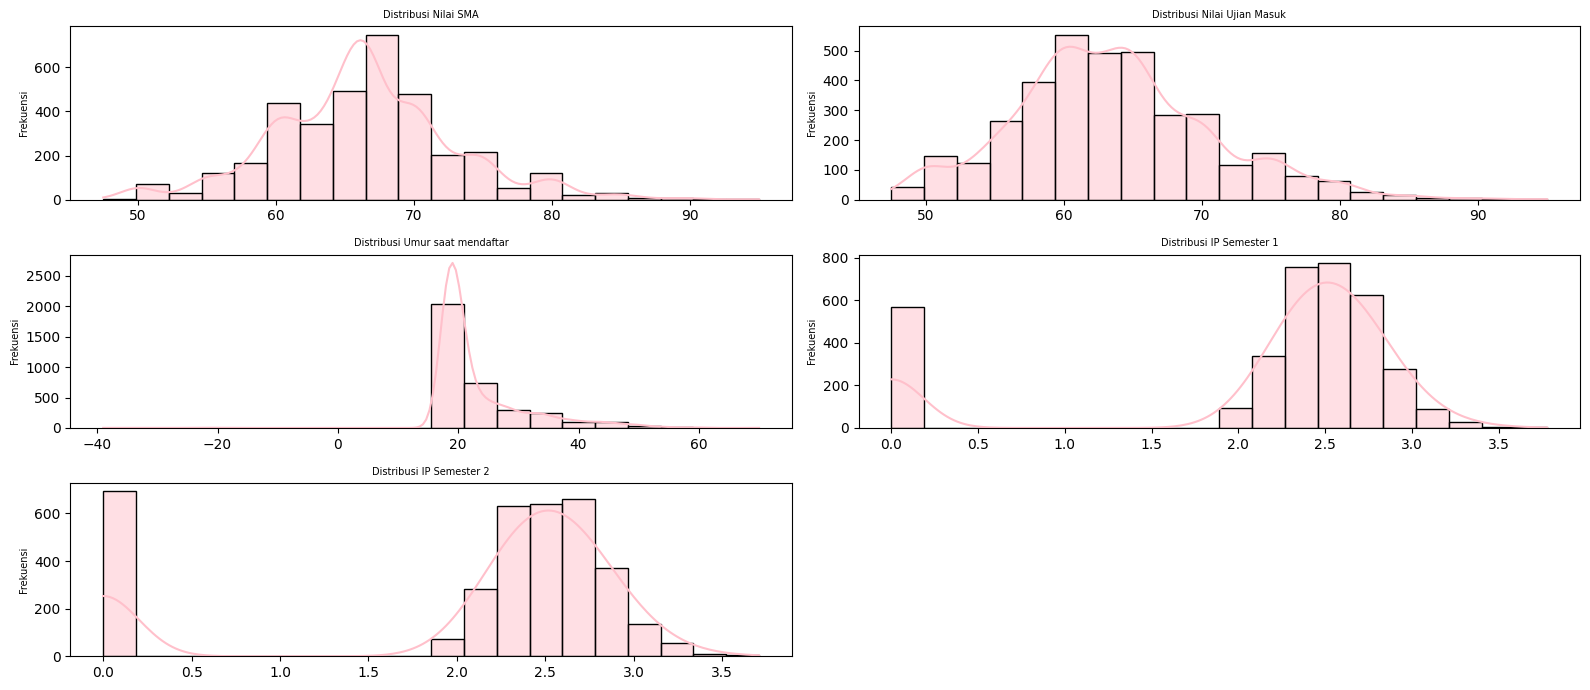

In [422]:
#mengimport library yang dibutuhkan
import matplotlib.pyplot as plt
import seaborn as sns

# 1)	Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
#menghitung histogram untuk fitur data numerik
Data_numerik = Data_Gabungan.select_dtypes(include=['int64', 'float64']).columns
#menghapus fitur "ID" karena setiap mahasiswa sudah pasti berbeda ID nya
Data_numerik = [col for col in Data_numerik if col != 'ID']
#membuat grafik batang data numerik
plt.figure(figsize=(16, 7))
for i, col in enumerate(Data_numerik, 1):
    plt.subplot(3, 2, i)
    sns.histplot(Data_Gabungan[col], kde=True, color='pink', bins=20)
    plt.title(f'Distribusi {col}', fontsize=7)
    plt.xlabel('')
    plt.ylabel('Frekuensi', fontsize=7)
plt.tight_layout()
plt.show()

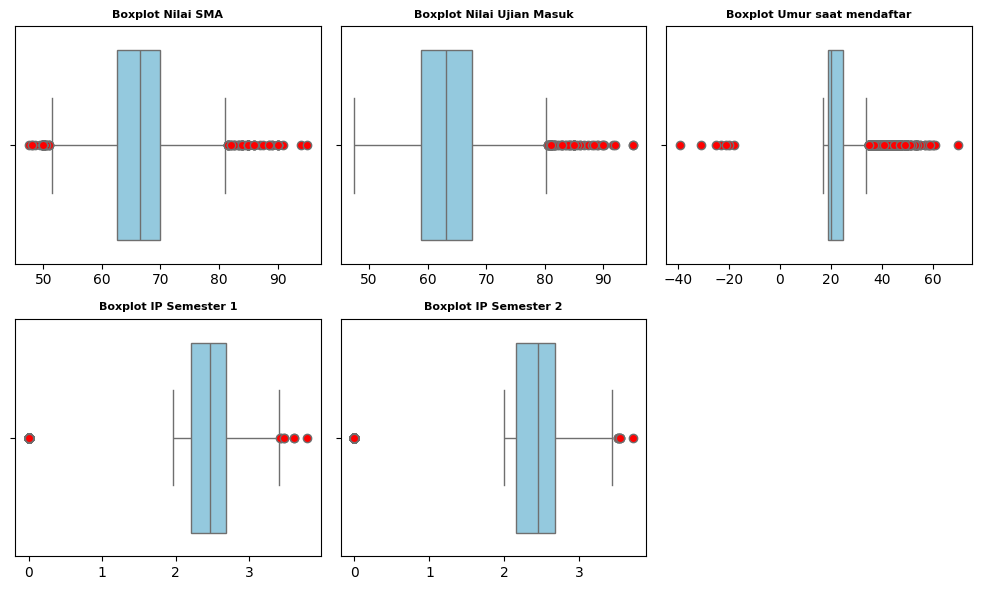

In [423]:
# 2)	Identifikasi outlier dengan boxplot
plt.figure(figsize=(10, 6))
for i, col in enumerate(Data_numerik, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=Data_Gabungan, x=col, color='skyblue', flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6})
    plt.title(f'Boxplot {col}', fontsize=8, fontweight='bold')
    plt.xlabel('')
plt.tight_layout()
plt.show()

bloxplot menunjukan outlier pada fitur "umur saat mendaftar" memiliki nilai ekstrem tinggi (menuju sisi kanan), namun ini hal yang wajar karena mahasiswa UT rata rata adalah pekerja dan berasal dari berbagai lintas usia. lalu pada fitur "IP semester 1" dan "IP semester 2" menunjukan nilai ekstrem rendah karena menuju ke nol. dimana mayoritas mahasiswa UT memiliki nilai yang bagus namun terdapat beberapa yang memiliki nilai yang anjlok. sedangkan untuk fitur "Nilai ujian masuk" dan "nilai SMA" bersih dari outlier.

In [424]:
# 3)	Hapus outlier dari data
Data = Data_Gabungan.copy()
# Hitung Q1, Q3, dan IQR
Q1 = Data['Umur saat mendaftar'].quantile(0.25)
Q3 = Data['Umur saat mendaftar'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas pagar aman
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Filter data: Ambil hanya data yang BERADA DI DALAM pagar aman
Data_Siap = Data[(Data['Umur saat mendaftar'] >= batas_bawah) &
                            (Data['Umur saat mendaftar'] <= batas_atas)]

print(u"Jumlah data fitur 'umur saat mendaftar' sebelum dibersihkan:", len(Data))
print(u"Jumlah data fitur 'umur saat mendaftar' setelah outlier dihapus:", len(Data_Siap))

Jumlah data fitur 'umur saat mendaftar' sebelum dibersihkan: 3557
Jumlah data fitur 'umur saat mendaftar' setelah outlier dihapus: 3197


In [425]:
# Hitung Q1, Q3, dan IQR
Q1 = Data_Siap['IP Semester 1'].quantile(0.25)
Q3 = Data_Siap['IP Semester 1'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas pagar aman
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Filter data: Ambil hanya data yang BERADA DI DALAM pagar aman
Data_Siap1 = Data_Siap[(Data_Siap['IP Semester 1'] >= batas_bawah) &
                            (Data_Siap['IP Semester 1'] <= batas_atas)]

print(u"Jumlah data fitur 'IP Semester 1' sebelum dibersihkan:", len(Data_Siap))
print(u"Jumlah data fitur 'IP Semester 1' setelah outlier dihapus:", len(Data_Siap1))

Jumlah data fitur 'IP Semester 1' sebelum dibersihkan: 3197
Jumlah data fitur 'IP Semester 1' setelah outlier dihapus: 2709


In [426]:
# Hitung Q1, Q3, dan IQR
Q1 = Data_Siap1['IP Semester 2'].quantile(0.25)
Q3 = Data_Siap1['IP Semester 2'].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas pagar aman
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Filter data: Ambil hanya data yang BERADA DI DALAM pagar aman
Data_Siap2 = Data_Siap1[(Data_Siap1['IP Semester 2'] >= batas_bawah) &
                            (Data_Siap1['IP Semester 2'] <= batas_atas)]

print(u"Jumlah data fitur 'IP Semester 2' sebelum dibersihkan:", len(Data_Siap1))
print(u"Jumlah data fitur 'IP Semester 2' setelah outlier dihapus:", len(Data_Siap2))

Jumlah data fitur 'IP Semester 2' sebelum dibersihkan: 2709
Jumlah data fitur 'IP Semester 2' setelah outlier dihapus: 2570


##Task 6
Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita melihat hubungan setiap fitur dengan kelas target.

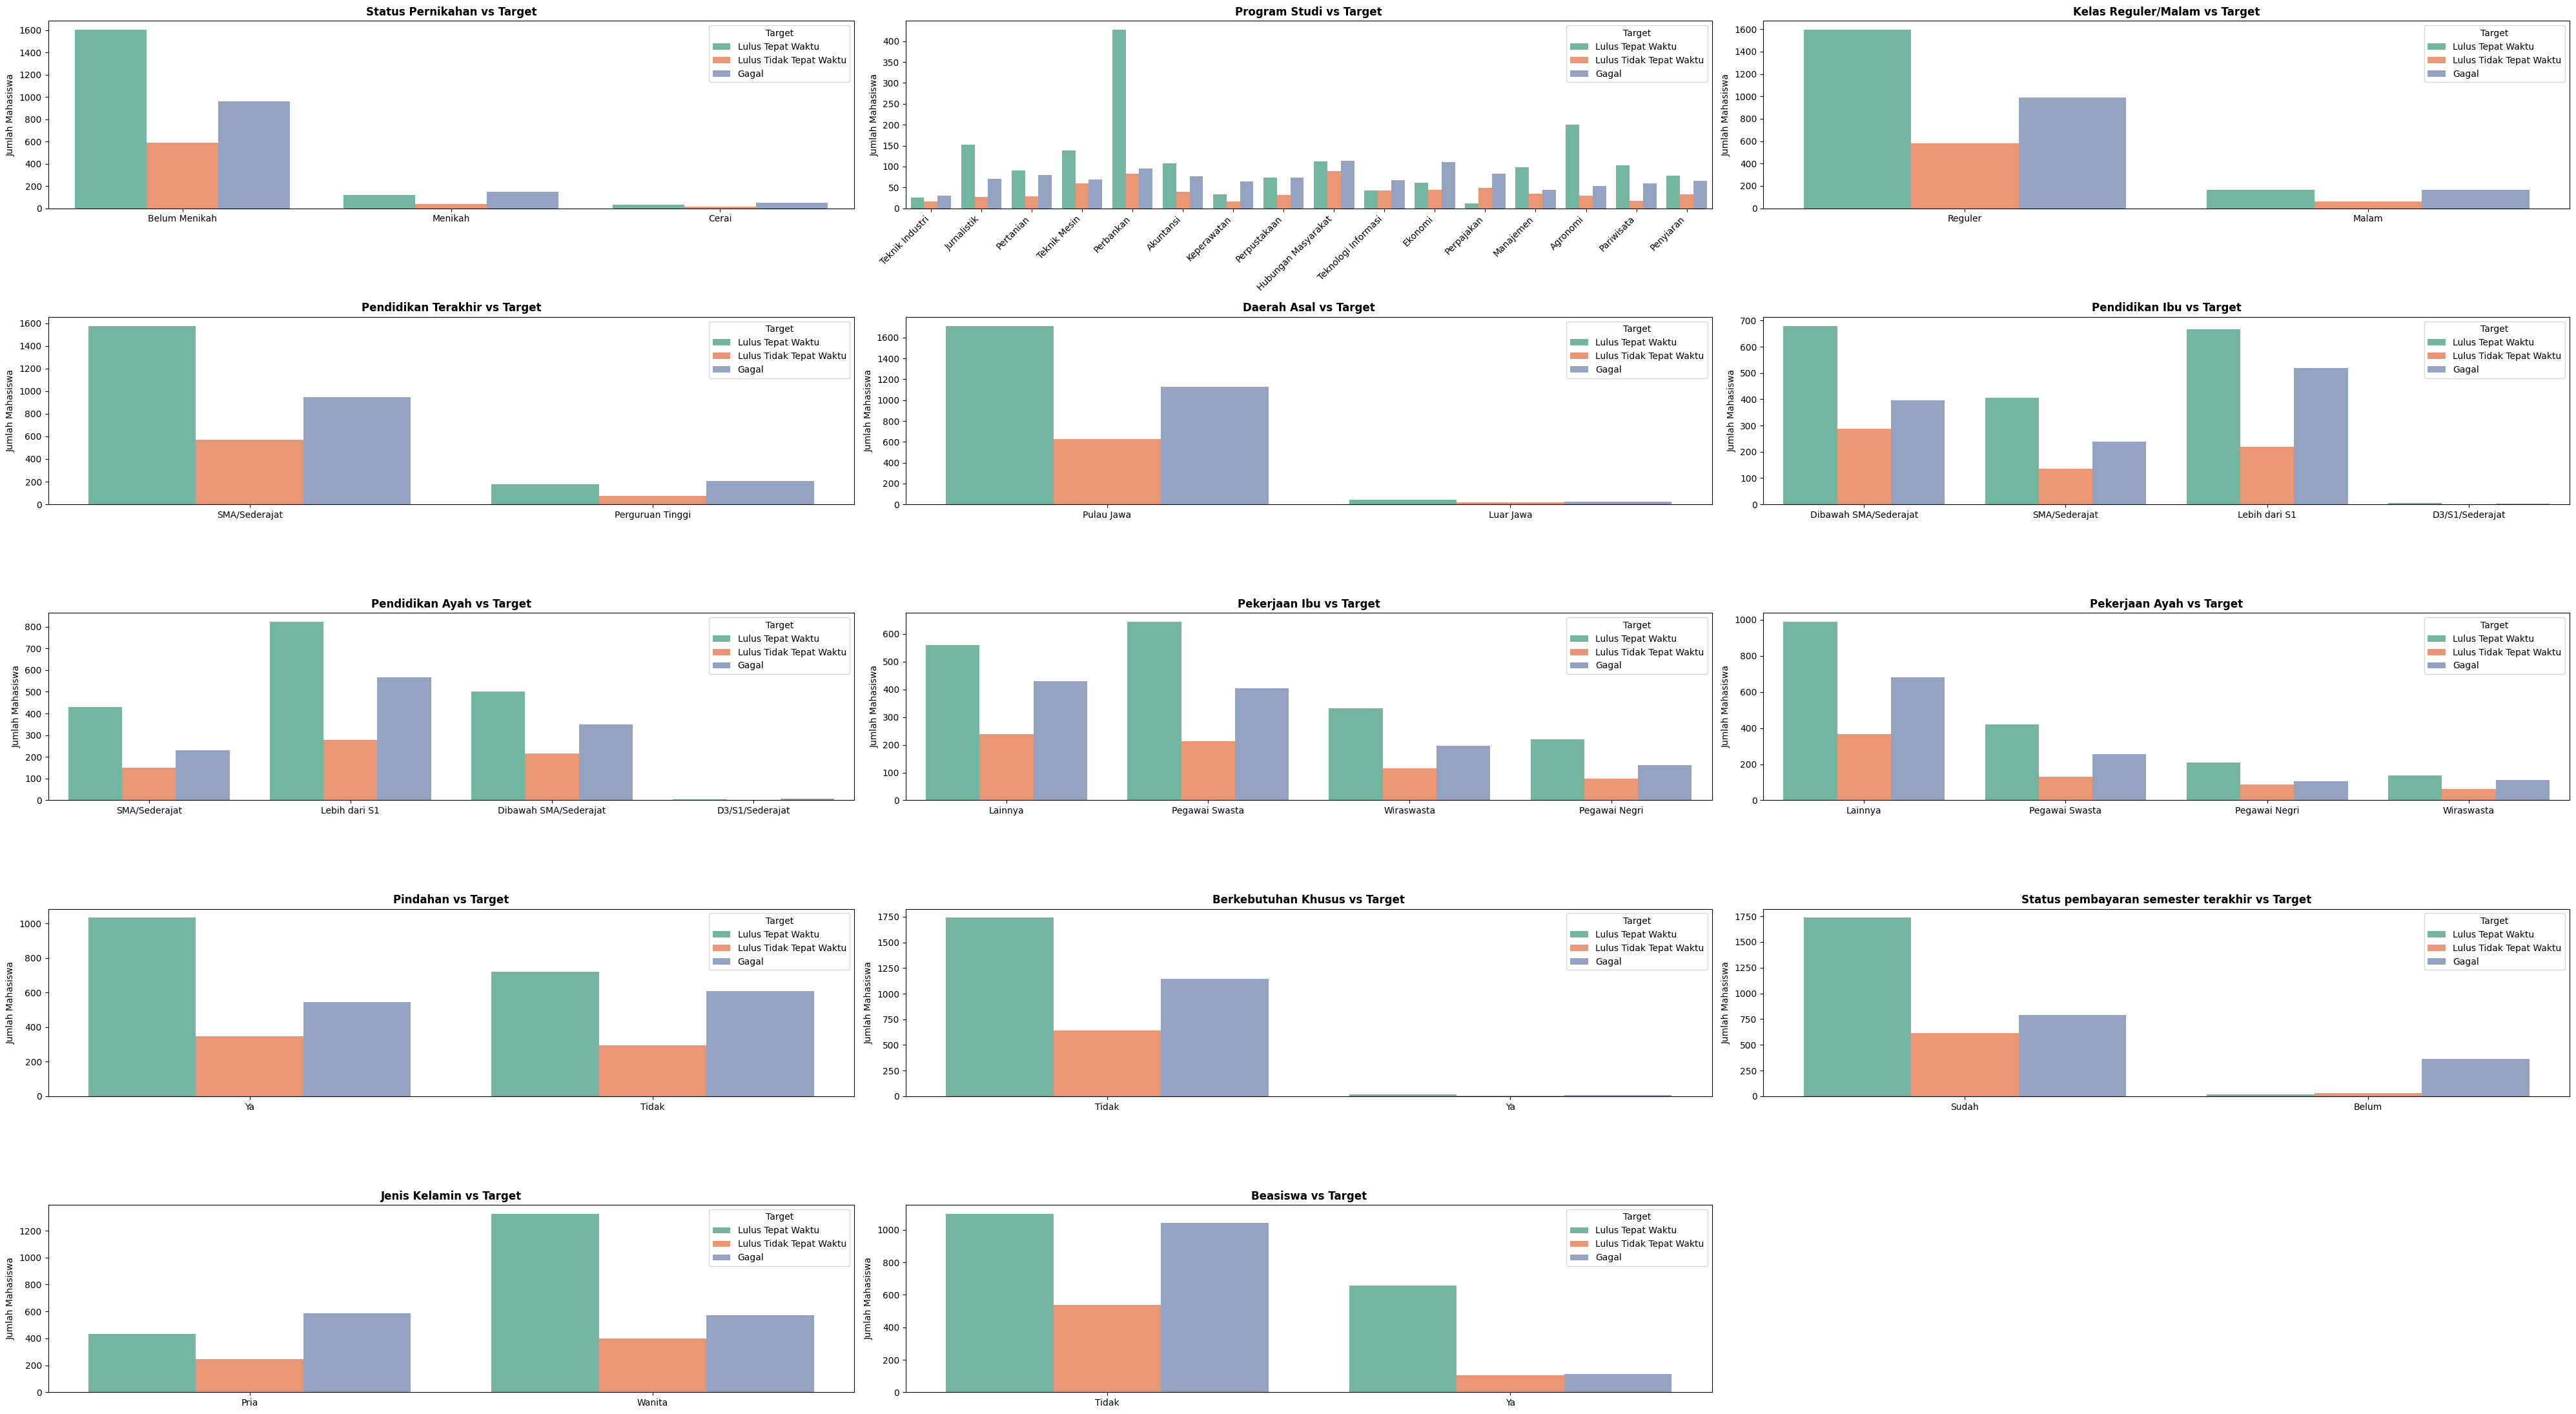

In [427]:
# 1)	Lakukan analisis bivariate
#analisis bivariat menunjukan hubungan target pada data kategori
plt.figure(figsize=(40, 22))
# Loop untuk menggambar grafik bar berpasangan
for i, col in enumerate(Data_kategori, 1):
    plt.subplot(5, 3, i)
    # hue diisi dengan 'Target' untuk membelah data berdasarkan status kelulusan
    sns.countplot(data=Data_Gabungan, x=col, hue='Target', palette='Set2')
    plt.title(f'{col} vs Target', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Jumlah Mahasiswa')
    # Khusus Program Studi labelnya dimiringkan agar muat
    if col == 'Program Studi':
        plt.xticks(rotation=45, ha='right')
    else:
        plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dari hasil diagram batang analisis bivariat data kategori terhadap target menunjukan bahwa setiap fitur nya memiliki hubungan terhadap target misalnya fitur status pembayaran semester terakhir yang menunjukan pengaruh signifikan terhadap target.

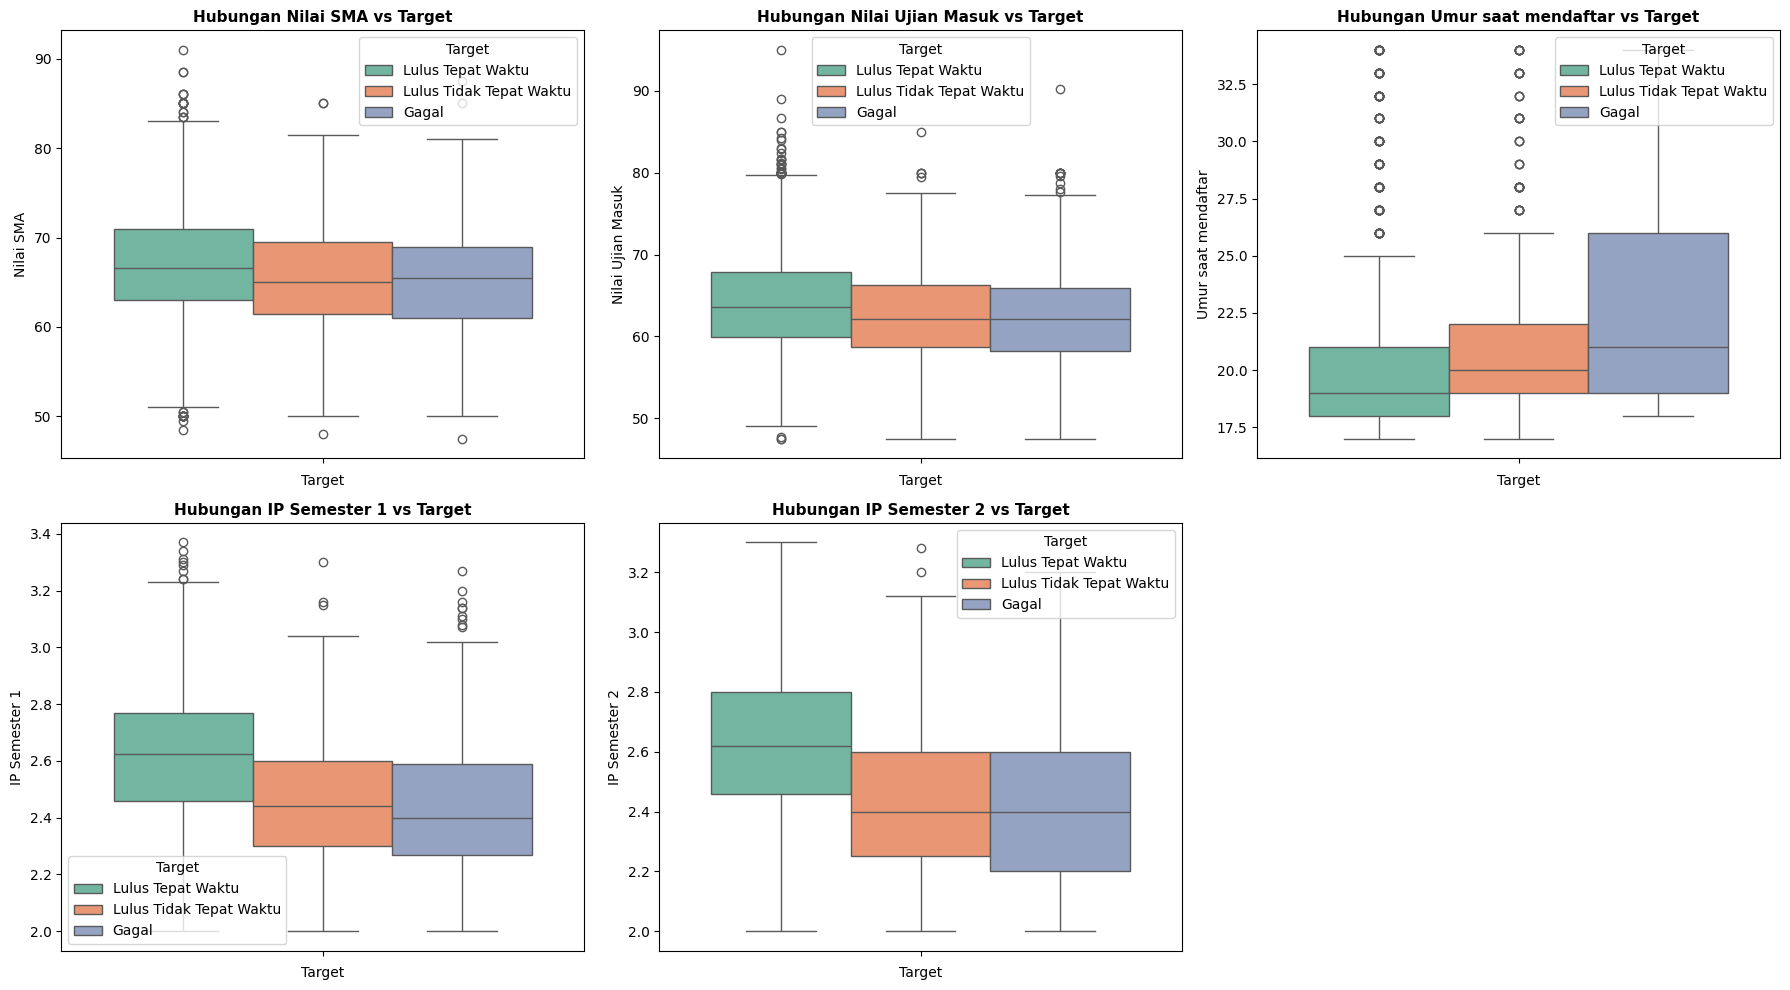

In [428]:
# analisis bivariat menunjukan hubungan target dengan data numerik
Fitur_numerik = Data_Siap2.select_dtypes(include=['int64', 'float64']).columns
#menghapus fitur "ID"
Fitur_numerik = [col for col in Fitur_numerik if col != 'ID']
#membuat
plt.figure(figsize=(18, 10))
for i, col in enumerate(Fitur_numerik, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=Data_Siap2, hue='Target', y=col, palette='Set2')
    plt.title(f'Hubungan {col} vs Target', fontsize=11, fontweight='bold')
    plt.xlabel('Target')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

dalam hasil bloxplot analisis bivariat data numerik terhadap target kita bisa melihat hubungan nya dan fitur apa yang mempengaruhi target. yaitu Hubungan IP semester 1 dan Hubungan IP semester 2 yang memiliki ketimpangan (tidak sejajar) yang menunjukan bahwa kedua fitur tersebut memiliki pengaruh yang kuat terhadap target

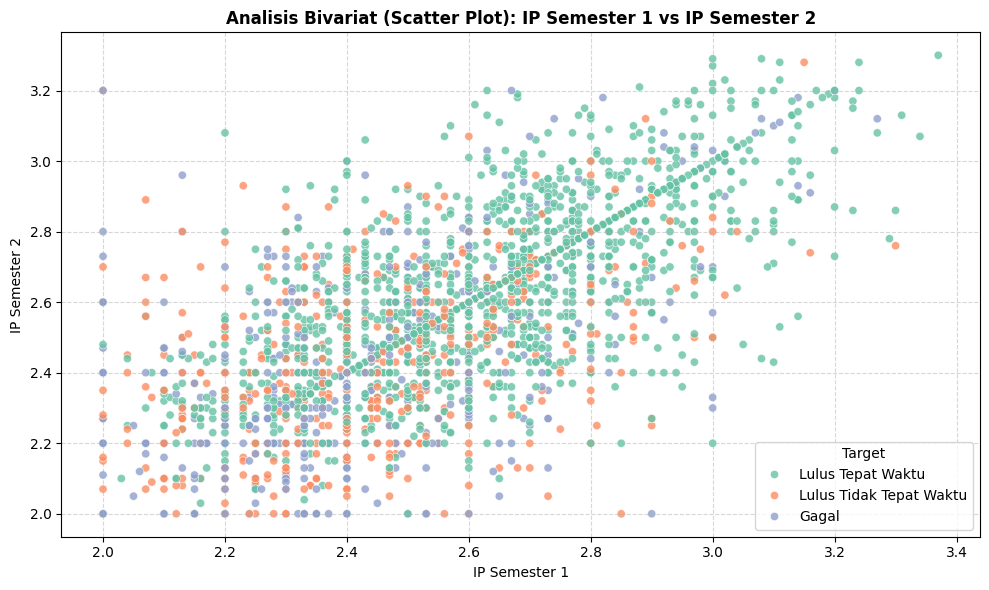

In [429]:

# 2) Plot kedalam grafik sebaran (scatter)
#menggunakan scatter plot untuk melihat hubungan (korelasi) 'IP Semester 1' dengan 'IP Semester 2' sebagai fitur yang sangat berpengaruh dalam menentukan kelulusan mahasiswa
plt.figure(figsize=(10, 6))
# Mempertemukan IP Semester 1 (Sumbu X) dan IP Semester 2 (Sumbu Y)
# hue ='Target' memberikan warna berbeda berdasarkan status kelulusan mahasiswa
sns.scatterplot(
    data=Data_Siap2,
    x='IP Semester 1',
    y='IP Semester 2',
    hue='Target',
    palette='Set2',
    alpha=0.8)
plt.title('Analisis Bivariat (Scatter Plot): IP Semester 1 vs IP Semester 2', fontsize=12, fontweight='bold')
plt.xlabel('IP Semester 1')
plt.ylabel('IP Semester 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Target')
plt.tight_layout()
plt.show()

dari scatter plot diatas diketahui bahwa semakin tinggi IP semester 1 dan IP Semester 2 seorang mahasiswa maka ia berpeluang tinggi untuk Lulus Tepat waktu di tujukan pada titik berwarna hijau yang semakin banyak di IP semester 1 dan Semester 2 pada titik 2.6 ke atas.

##Task 7
Oke, sepertinya sudah siap, tapi kok jumlah data per-kelas nya tidak seimbang ya, ada beberapa algoritma yang akan terpengaruh dengan kondisi ini, kita akan gunakan algoritma **$\color{orange}{\text{(Random Forest)}}$** untuk menyelesaikan masalah ini, jadi kita **$\color{orange}{\text{(tidak akan)}}$** melakukan proses augmentasi data karena **$\color{orange}{\text{(algoritma ini cocok terhadap data yang tidak seimbang, dimana digunakan  class_weight='balanced)}}$**

Selanjutnya datanya perlu kita bagi dengan ratio **$\color{orange}{\text{(80)}}$** : **$\color{orange}{\text{(20)}}$**
Dimana **$\color{orange}{\text{(80)}}$** adalah data training
Dan **$\color{orange}{\text{(20)}}$** adalah data testing


In [438]:
# 1)	Lakukan pembagian data training dan testing
# Pisahkan fitur (X) dan target (y)
# Hapus kolom 'ID' karena tidak memiliki pola, dan 'Target' karena itu yang ditebak
X = Data_Siap2.drop(columns=['ID', 'Target'])
y = Data_Siap2['Target']

# Ubah data teks/kategori menjadi angka (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3) Lakukan pembagian data training dan testing (80:20)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_encoded, y, test_size=0.2, random_state=80, stratify=y)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 2056
Jumlah data testing: 514


##Task 8
Sekarang kita mulai training nya

In [439]:
# 1)	Lakukan proses training dengan algoritma Random Forest
#import library yang diperlukan
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42

)

# 2) Lakukan evaluasi model dengan K-fold pada data training
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
model.fit(X_train, y_train)
print("Akurasi tiap lipatan (fold):", cv_scores)
print(f"Rata-rata Akurasi Cross-Validation: {cv_scores.mean() * 100:.2f}%")

Akurasi tiap lipatan (fold): [0.65048544 0.62773723 0.62773723 0.63990268 0.62043796]
Rata-rata Akurasi Cross-Validation: 63.33%


#Task 9
Training sudah selesai dan model sudah diketahui, kita uji hasilnya dengan data testing untuk melihat kemungkinan overfitting dan underfitting, sekaligus menghitung kualitas model dengan matrik pengukuran

In [440]:
# 1)	Evaluasi dengan data testing
#import library yang dibutuhkan
from sklearn.metrics import classification_report, accuracy_score
# Evaluasi dengan data testing
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
print(f"Akurasi Training: {train_acc * 100:.2f}%")
print(f"Akurasi Testing: {test_acc * 100:.2f}%\n")

# Cek Indikasi Overfitting/Underfitting
if train_acc > test_acc + 0.1:
    print("Indikasi: Model kemungkinan overfitting")
elif test_acc > train_acc + 0.1:
    print("Indikasi: Model kemungkinan underfitting")
else:
    print("Indikasi: Model dalam batas wajar dan stabil")

# 2) Hitung dengan matrik pengukuran yang lebih lengkap
print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(y_test, y_pred_test))

Akurasi Training: 77.43%
Akurasi Testing: 64.20%

Indikasi: Model kemungkinan overfitting

Laporan Klasifikasi (Classification Report):
                         precision    recall  f1-score   support

                  Gagal       0.55      0.54      0.54        96
      Lulus Tepat Waktu       0.82      0.74      0.78       312
Lulus Tidak Tepat Waktu       0.34      0.44      0.39       106

               accuracy                           0.64       514
              macro avg       0.57      0.58      0.57       514
           weighted avg       0.67      0.64      0.65       514



##Task 10
Berdasarkan hasil evaluasi, kita bisa menyimpulkan bahwa

**$\color{orange}{\text{( model berkemungkinan besar overfitting karena terlalu menghapal data latih sehingga kesulitan saat menangani data baru
dapat dilihat dari Kinerja Metrik yang Imbalanced. Karena fokus utama masalah ini adalah peringatan dini mahasiswa berisiko (kelas "Gagal"), metrik yang paling relevan untuk diperhatikan adalah Recall untuk kelas "Gagal".
dan Saran Pengembangan Lanjutan Untuk meningkatkan performa Recall dan menekan overfitting, ke depannya dapat dilakukan Hyperparameter Tuning (misalnya mengurangi `max_depth` lebih jauh,
memperbesar `min_samples_leaf`, atau
mencoba menggunakan teknik agregasi data seperti SMOTE jika penyesuaian bobot kelas masih dirasa kurang).)}}$**